In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

DATA_ROOT = os.path.join(PROJECT_ROOT, "data")

In [2]:
os.getcwd()

'/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/VisualBertModel'

In [3]:
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, VisualBertForQuestionAnswering
from utils.slake_datasets import VisualBERTSlakeDataset
from utils.vqa_rad_dataset import VQARadVisualBERTDataset
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline

/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class VisualFeatureExtract(nn.Module):

    def __init__(self):
        super().__init__()
        backbone = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.DEFAULT
        )
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.backbone.eval()

        for param in self.backbone.parameters():
            param.requires_grad = False

    def forward(self, images):
        with torch.no_grad():
            features = self.backbone(images)            # [B, 2048, 1, 1]
        features = features.squeeze(-1).squeeze(-1)     # [B, 2048]

        return features

In [5]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, checkpoint_path="outputs/checkpoints/visualbert_best.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False
        self.checkpoint_path = checkpoint_path
        os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.checkpoint_path)
            print(f"✓ Validation improved → checkpoint saved")
        else:
            self.counter += 1
            print(f"Early Stopping {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

In [6]:
def vqa_collate_fn(batch):
    """
    Custom collate function to handle text fields (question, answer)
    without converting them to tensors.
    """
    images = torch.stack([b["image"] for b in batch])
    input_ids = torch.stack([b["input_ids"] for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])

    questions = [b["question"] for b in batch]   # keep as list[str]
    answers = [b["answer"] for b in batch]       # keep as list[str]

    return {
        "image": images,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "question": questions,
        "answer": answers,
    }

In [7]:
# TRAINING PIPELINE
def train_for_one_epoch(model, visual_features_extractor, loader, optimizer, criterion, answer_to_idx, device):

    model.train()

    total_loss = 0
    total_training = 0
    training_error = 0

    visual_sequence_length = 10

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        labels = torch.tensor(
            [answer_to_idx.get(str(ans).lower().strip(), answer_to_idx["UNK"]) for ans in batch["answer"]],
            dtype=torch.long,
            device=device
        )

        # VISUAL EMBEDDINGS
        visual_features = visual_features_extractor(images)
        visual_embeds = visual_features.unsqueeze(1).expand(
            visual_features.size(0), visual_sequence_length, visual_features.size(1)
        )

        visual_token_type_ids = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.long, device=device
        )

        visual_attention_mask = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.float, device=device
        )

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids
        )

        logits = outputs.logits
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        training_error += (preds != labels).sum().item()
        total_training += labels.size(0)

    return  total_loss / len(loader), 100 * (1 - training_error / total_training)



In [8]:
# EVALUATION PIPELINE - Filtering unseen words with (UNK) token
@torch.no_grad()
def evaluate(model, visual_features_extractor, loader, criterion, answer_to_idx, device):

    model.eval()

    total_loss = 0.0
    total_eval = 0
    eval_error = 0

    # ---- for analysis & plots ----
    all_preds = []
    all_labels = []
    all_oov_flags = []

    visual_sequence_length = 10
    unk_idx = answer_to_idx["UNK"]

    for batch in loader:
        labels = []
        oov_flags = []

        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # ---- label + OOV tracking ----
        for ans in batch["answer"]:
            if ans in answer_to_idx:
                labels.append(answer_to_idx[ans])
                oov_flags.append(0)
            else:
                labels.append(unk_idx)
                oov_flags.append(1)

        labels = torch.tensor(labels, dtype=torch.long, device=device)

        # ---- visual embeddings ----
        visual_features = visual_features_extractor(images)
        visual_embeds = visual_features.unsqueeze(1).expand(
            visual_features.size(0),
            visual_sequence_length,
            visual_features.size(1)
        )

        visual_token_type_ids = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.long, device=device
        )

        visual_attention_mask = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.float, device=device
        )

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids,
        )

        logits = outputs.logits
        loss = criterion(logits, labels)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        eval_error += (preds != labels).sum().item()
        total_eval += labels.size(0)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_oov_flags.extend(oov_flags)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * (1 - eval_error / total_eval)

    return (
        avg_loss,
        accuracy,
        np.asarray(all_preds, dtype=int),
        np.asarray(all_labels, dtype=int),
        np.asarray(all_oov_flags, dtype=int)
        )


@torch.no_grad()
def evaluate_excluding_unk(model, visual_features_extractor, loader, criterion, answer_to_idx, device):
    
    model.eval()

    total_loss = 0
    total_eval = 0
    eval_error = 0

    visual_sequence_length = 10
    unk_idx = answer_to_idx["UNK"]

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Map unseen answers to "UNK"
        labels = [
            answer_to_idx.get(str(ans).lower().strip(), unk_idx) for ans in batch["answer"]
        ]
        labels = torch.tensor(labels, dtype=torch.long, device=device)

        # Skip samples with UNK labels
        mask = labels != unk_idx
        if mask.sum() == 0:
            continue

        # VISUAL EMBEDDINGS
        visual_features = visual_features_extractor(images)
        visual_embeds = visual_features.unsqueeze(1).expand(
            visual_features.size(0), visual_sequence_length, visual_features.size(1)
        )

        visual_token_type_ids = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.long, device=device
        )

        visual_attention_mask = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.float, device=device
        )

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids,
        )

        logits = outputs.logits
        loss = criterion(logits[mask], labels[mask])

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        eval_error += (preds[mask] != labels[mask]).sum().item()
        total_eval += mask.sum().item()

    return  total_loss / len(loader), 100 * (1 - eval_error / total_eval)

@torch.no_grad()
def evaluate_open_ended(model, visual_features_extractor, loader, idx_to_answer, tokenizer, device, num_examples=10, save_dirs="outputs/failures"):
    
    os.makedirs(save_dirs, exist_ok=True)
    
    model.eval()

    visual_sequence_length = 10
    failures = 0

    print("\n===== GROUND TRUTH EVALUATION FOR OPEN-ENDED=====\n")

    for batch in loader:
        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # VISUAL EMBEDDINGS
        visual_features = visual_features_extractor(images)
        visual_embeds = visual_features.unsqueeze(1).expand(
            visual_features.size(0), visual_sequence_length, visual_features.size(1)
        )
        visual_attention_mask = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.float, device=device
        )
        visual_token_type_ids = torch.ones(
            visual_embeds.shape[:-1], dtype=torch.long, device=device
        )

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids
        )

        preds = outputs.logits.argmax(dim=1).cpu().tolist()

        for i, pred in enumerate(preds):
            ground_truth = batch["answer"][i]
            pred_ans = idx_to_answer[pred]

            if pred_ans != ground_truth:
                question = batch["question"][i] if "question" in batch else tokenizer.decode(input_ids[i], skip_special_tokens=True)
                img = images[i].cpu().permute(1, 2, 0)
                img = (img - img.min()) / (img.max() - img.min())

                plt.figure(figsize=(4,4))
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"Question: {question}\nGround Truth: {ground_truth}\nPred: {pred_ans}", fontsize=8)
                filename = f"failure_{failures+1}.png"

                plt.savefig(os.path.join(save_dirs, filename), dpi=300)
                plt.show()
                #plt.close()

                print(f"[SAMPLE {failures+1}] Question: {question} | Ground Truth: {ground_truth} | Pred: {pred_ans}")
                
                failures += 1

                if failures >= num_examples:
                    return


In [14]:
# LEARNING CURVES
def plot_learning_curves(train_losses, validation_losses, train_accuracies, validation_accuracies, save_dir="outputs/plots"):
    os.makedirs(save_dir, exist_ok=True)
    epochs = range(1, len(train_losses)+1)

    # LOSS PLOT
    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss", marker='o', color='blue')
    plt.plot(epochs, validation_losses, label="Validation Loss (Excluding OOV Answer)", marker='s', color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss (VisualBERT on VQA-RAD)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "loss_curve.png"), dpi=300)
    plt.show()
    # plt.close()

    # ACCURACY
    plt.figure()
    plt.plot(epochs, train_accuracies, label="Train Accuracy", marker='o', color='blue')
    plt.plot(epochs, validation_accuracies, label="Validation Accuracy (Excluding OOV Answer)", marker='s', color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training vs Validation Accuracy (VisualBERT on VQA-RAD)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, "accuracy_curve.png"), dpi=300)
    plt.show()
    # plt.close()

In [10]:
# OOV PERCENTAGE
def compute_oov(oov_flags):
    oov_flags = np.array(oov_flags)

    if oov_flags.ndim == 0:
        oov_flags = np.array([oov_flags])

    if oov_flags.dtype.kind in {'U', 'S'}:  # string types
        oov_flags = oov_flags == 'True'
    
    # Convert boolean to int
    oov_flags = oov_flags.astype(int)
    
    return 100 * (oov_flags.sum() / len(oov_flags))

In [11]:
# CONFUSION MATRIX FOR CLOSED-ENDED QUESTIONS
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(preds, labels, class_names, title, save_path):
    cm = confusion_matrix(y_true=labels, y_pred=preds, labels=range(len(class_names)))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.savefig(save_path)
    plt.show()

## VisualBERT On SLAKE (EN Version)

In [24]:
# MAIN (slake)
def main_slake():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406],     # ImageNet Normalization
            std=[0.229, 0.224, 0.225]
        ),
    ])

    tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

    # --- DATASET ---
    train_data = VisualBERTSlakeDataset(
        annotations_path=os.path.join(DATA_ROOT, "SLAKE/annotations/train_en.json"),
        image_root=os.path.join(DATA_ROOT, "SLAKE/imgs"),
        tokenizer=tokenizer,
        transform=transform
    )

    validation_data = VisualBERTSlakeDataset(
        annotations_path=os.path.join(DATA_ROOT, "SLAKE/annotations/validation_en.json"),
        image_root=os.path.join(DATA_ROOT, "SLAKE/imgs"),
        tokenizer=tokenizer,
        transform=transform
    )

    test_data = VisualBERTSlakeDataset(
        annotations_path=os.path.join(DATA_ROOT, "SLAKE/annotations/test_en.json"),
        image_root=os.path.join(DATA_ROOT, "SLAKE/imgs"),
        tokenizer=tokenizer,
        transform=transform
    )

    # --- DATALOADERS ---
    train_loader = DataLoader(
        train_data,
        batch_size=8,
        shuffle=True,
        num_workers=4
    )

    validation_loader = DataLoader(
        validation_data,
        batch_size=8,
        shuffle=False,
        num_workers=4
    )

    test_loader = DataLoader(
        test_data,
        batch_size=8,
        shuffle=False,
        num_workers=4
    )

    # --- ANSWER VOCAB ---
    train_answer = {str(sample["answer"]).strip().lower() for sample in train_data.samples}
    answers = sorted(train_answer)

    #if "UNK" not in answers:
    answers.append("UNK")
    
    answer_to_idx = {ans: i for i, ans in enumerate(answers)}
    idx_to_answer = {i: ans for ans, i in answer_to_idx.items()}

    unk_idx = answer_to_idx["UNK"]

    # --- MODELS ---
    model = VisualBertForQuestionAnswering.from_pretrained(
        "uclanlp/visualbert-vqa-coco-pre",
        num_labels=len(answer_to_idx)).to(device)

    visual_extractor = VisualFeatureExtract().to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    criterion = nn.CrossEntropyLoss()

    # --- EARLY STOPPING ---
    early_stopping = EarlyStopping(patience=2, checkpoint_path="outputs/checkpoints/visualbert_slake_best.pt")

    # --- TRAINING ---
    epochs = 5

    train_losses, validation_losses = [], []
    train_accs, validation_accs = [], []

    print("\n===== PERFORMANCE METRICS =====\n")

    for epoch in range(epochs):
        train_loss, train_accuracy = train_for_one_epoch(
            model=model,
            visual_features_extractor=visual_extractor,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            answer_to_idx=answer_to_idx,
            device=device
        )

        validation_loss, validation_accuracy = evaluate_excluding_unk(
            model=model,
            visual_features_extractor=visual_extractor,
            loader=validation_loader,
            criterion=criterion,
            answer_to_idx=answer_to_idx,
            device=device
        )

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        train_accs.append(train_accuracy)
        validation_accs.append(validation_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Training Loss: {train_loss:.4f} | "
            f"Training Accuracy: {train_accuracy:.2f}% | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Validation Accuracy (Excluding UNK): {validation_accuracy:.2f}%"
        )

        early_stopping(validation_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # --- PLOT CURVES ---
    plot_learning_curves(train_losses, validation_losses, train_accs, validation_accs)

    # --- EVAL ON BEST MODEL ---
    model.load_state_dict(
        torch.load("outputs/checkpoints/visualbert_slake_best.pt", map_location=device))
    
    model.eval()

    # --- OOV PERCENTAGE ---
    _, _, _, _, slake_oov_flags = evaluate(
    model=model,
    visual_features_extractor=visual_extractor,
    loader=validation_loader,
    criterion=criterion,
    answer_to_idx=answer_to_idx,
    device=device
    )
    # assert isinstance(slake_oov_flags, tuple), f"evaluate() returned {type(slake_oov_flags)}"
    slake_oov = compute_oov(slake_oov_flags)

    #print("\n===== SLAKE OOV PERCENTAGE =====")
    print(f"SLAKE OOV RATE: {slake_oov:.2f}%")

    # --- TEST EVALUATION ---
    print("\n===== MODEL PERFORMANCE ON TEST DATA INCLUDING OOV =====\n")

    test_loss, test_accuracy, all_predictions, all_labels, oov_flags = evaluate(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        criterion=criterion,
        answer_to_idx=answer_to_idx,
        device=device
    )

    

    print(f"Test Loss: {float(test_loss):.4f} | Test Accuracy: {float(test_accuracy):.2f}%")

    print("\n===== MODEL PERFORMANCE ON TEST DATA EXCLUDING OOV =====\n")
    
    test_loss_ex, test_accuracy_ex = evaluate_excluding_unk(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        criterion=criterion,
        answer_to_idx=answer_to_idx,
        device=device
    )

    print(f"Test Loss: {test_loss_ex:.4f} | Test Accuracy: {test_accuracy_ex:.2f}%")

    # --- CONFUSION MATRIX FOR CLOSED-ENDED QUESTIONS ---
    #closed_indices = [answer_to_idx["yes"], answer_to_idx["no"]]

    closed_answer_texts = {"yes", "no"}

    closed_answer_indices = [
        answer_to_idx[a]
        for a in closed_answer_texts
        if a in answer_to_idx
    ]

    closed_mask = [label in closed_answer_indices for label in all_labels]

    closed_preds = [p for p, m in zip(all_predictions, closed_mask) if m]
    closed_labels = [l for l, m in zip(all_labels, closed_mask) if m]

    # Map global → local
    label_remap = {
        closed_answer_indices[0]: 0,
        closed_answer_indices[1]: 1
    }
    
    closed_preds_local = [label_remap[p] for p in closed_preds if p in label_remap]
    closed_labels_local = [label_remap[l] for l in closed_labels]


    if len(closed_labels_local) == 0:
        print("⚠️ No closed-ended (yes/no) questions found in this split.")
    else:
        plot_confusion_matrix(
        preds=closed_preds_local,
        labels=closed_labels_local,
        class_names=["yes", "no"],
        title="SLAKE Closed-Ended Confusion Matrix",
        save_path="outputs/plots/slake_closed_cm.png"
    )
        
    print("Closed answer indices:", closed_answer_indices)
    print("Number of closed-ended samples:", len(closed_labels))


    # --- TOP-K FREQUENT ANSWERS FOR OPEN-ENDED QUESTIONS ---
    TOP_K = 10

    common_label = [
        l for l, _ in Counter(all_labels).most_common(TOP_K)
    ]

    open_mask = [label in common_label for label in all_labels]

    open_preds = [p for p, m in zip(all_predictions, open_mask) if m]
    open_labels = [l for l, m in zip(all_labels, open_mask) if m]

    plot_confusion_matrix(
        preds=open_preds,
        labels=open_labels,
        class_names=[idx_to_answer[i] for i in common_label],
        title="SLAKE TOP-K Frequent Answers Confusion Matrix",
        save_path="outputs/plots/slake_open_topk_cm.png"
    )

    # QUALITATIVE EVALUATION ON TESTING DATA
    evaluate_open_ended(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        idx_to_answer=idx_to_answer,
        tokenizer=tokenizer,
        device=device,
        num_examples=5
    )


Some weights of VisualBertForQuestionAnswering were not initialized from the model checkpoint at uclanlp/visualbert-vqa-coco-pre and are newly initialized: ['cls.bias', 'cls.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== PERFORMANCE METRICS =====

Epoch [1/5] | Training Loss: 2.0052 | Training Accuracy: 49.91% | Validation Loss: 1.2215 | Validation Accuracy (Excluding UNK): 62.57%
✓ Validation improved → checkpoint saved
Epoch [2/5] | Training Loss: 1.0650 | Training Accuracy: 68.47% | Validation Loss: 0.8865 | Validation Accuracy (Excluding UNK): 72.10%
✓ Validation improved → checkpoint saved
Epoch [3/5] | Training Loss: 0.8085 | Training Accuracy: 75.63% | Validation Loss: 0.7788 | Validation Accuracy (Excluding UNK): 74.29%
✓ Validation improved → checkpoint saved
Epoch [4/5] | Training Loss: 0.6670 | Training Accuracy: 79.83% | Validation Loss: 0.6544 | Validation Accuracy (Excluding UNK): 80.19%
✓ Validation improved → checkpoint saved
Epoch [5/5] | Training Loss: 0.5696 | Training Accuracy: 81.81% | Validation Loss: 0.7153 | Validation Accuracy (Excluding UNK): 77.43%
Early Stopping 1/2


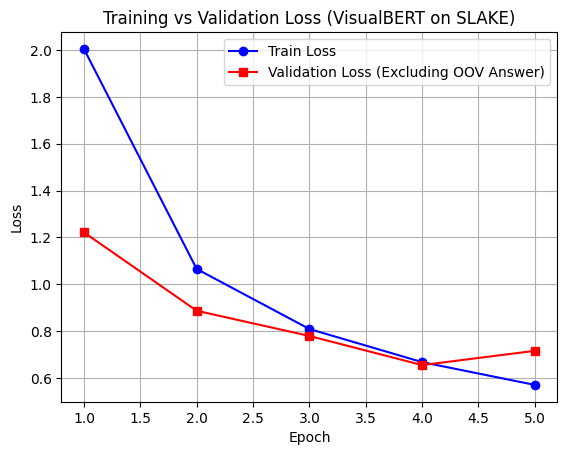

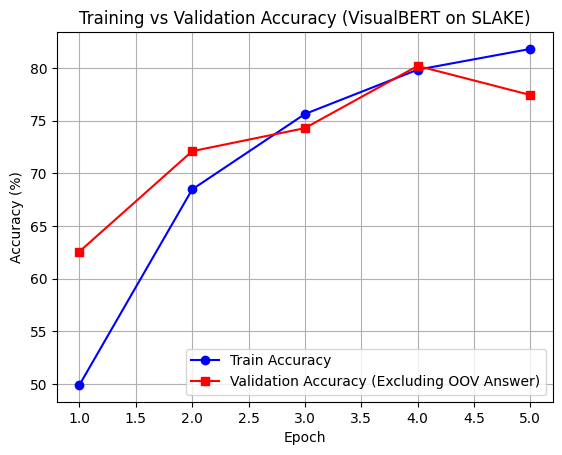

SLAKE OOV RATE: 94.68%

===== MODEL PERFORMANCE ON TEST DATA INCLUDING OOV =====

Test Loss: 10.0545 | Test Accuracy: 3.11%

===== MODEL PERFORMANCE ON TEST DATA EXCLUDING OOV =====

Test Loss: 0.7291 | Test Accuracy: 76.68%
⚠️ No closed-ended (yes/no) questions found in this split.
Closed answer indices: [141, 220]
Number of closed-ended samples: 0


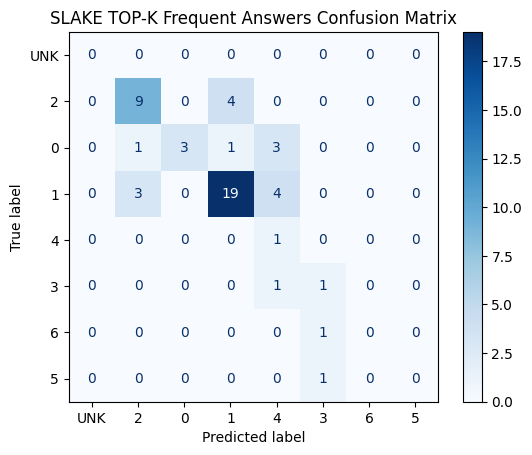


===== GROUND TRUTH EVALUATION FOR OPEN-ENDED=====



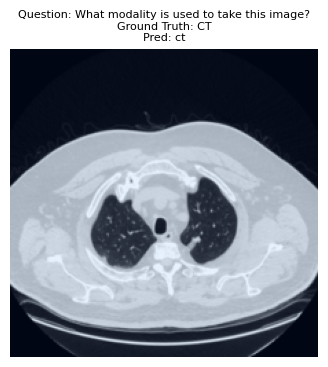

[SAMPLE 1] Question: What modality is used to take this image? | Ground Truth: CT | Pred: ct


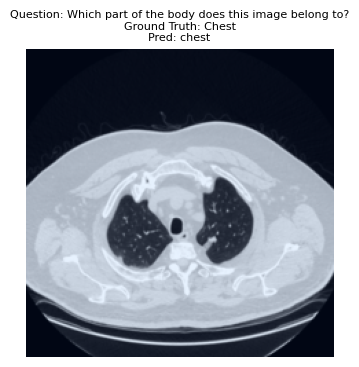

[SAMPLE 2] Question: Which part of the body does this image belong to? | Ground Truth: Chest | Pred: chest


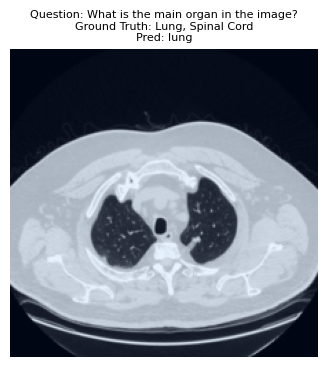

[SAMPLE 3] Question: What is the main organ in the image? | Ground Truth: Lung, Spinal Cord | Pred: lung


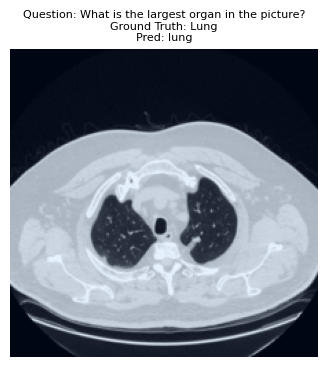

[SAMPLE 4] Question: What is the largest organ in the picture? | Ground Truth: Lung | Pred: lung


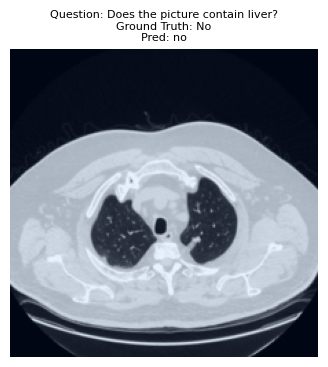

[SAMPLE 5] Question: Does the picture contain liver? | Ground Truth: No | Pred: no


In [25]:
main_slake()

## VisualBERT On VQA-RAD

In [15]:
def main_vqa():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
    ])

    tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

    train_data = VQARadVisualBERTDataset(
        annotations_path=os.path.join(DATA_ROOT, "VQA_RAD/train.json"), 
        image_root=os.path.join(DATA_ROOT, "VQA_RAD/images"), 
        tokenizer=tokenizer, 
        transform=transform
    )

    val_data = VQARadVisualBERTDataset(
        annotations_path=os.path.join(DATA_ROOT, "VQA_RAD/val.json"), 
        image_root=os.path.join(DATA_ROOT, "VQA_RAD/images"), 
        tokenizer=tokenizer, 
        transform=transform
    )

    test_data = VQARadVisualBERTDataset(
        annotations_path=os.path.join(DATA_ROOT, "VQA_RAD/test.json"), 
        image_root=os.path.join(DATA_ROOT, "VQA_RAD/images"), 
        tokenizer=tokenizer, 
        transform=transform
    )

    train_loader = DataLoader(
        train_data, 
        batch_size=8, 
        shuffle=True, 
        collate_fn=vqa_collate_fn
    )

    val_loader = DataLoader(
        val_data, 
        batch_size=8, 
        shuffle=False, 
        collate_fn=vqa_collate_fn
    )

    test_loader = DataLoader(
        test_data, 
        batch_size=8, 
        shuffle=False, 
        collate_fn=vqa_collate_fn
    )

    answers = sorted({str(s["answer"]).lower().strip() for s in train_data.samples})

    #if "UNK" not in answers:
    answers.append("UNK")
    
    answer_to_idx = {a: i for i, a in enumerate(answers)}
    idx_to_answer = {i: a for a, i in answer_to_idx.items()}
    unk_idx = answer_to_idx["UNK"]

    model = VisualBertForQuestionAnswering.from_pretrained(
        "uclanlp/visualbert-vqa-coco-pre",
        num_labels=len(answer_to_idx)).to(device)

    visual_extractor = VisualFeatureExtract().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=2, checkpoint_path="outputs/checkpoints/visualbert_vqa_rad_best.pt")

    train_losses, validation_losses = [], []
    train_accs, validation_accs = [], []
    epochs = 5

    for epoch in range(epochs):
        train_loss, train_accuracy = train_for_one_epoch(
            model=model, 
            visual_features_extractor=visual_extractor, 
            loader=train_loader, 
            optimizer=optimizer, 
            criterion=criterion, 
            answer_to_idx=answer_to_idx, 
            device=device
        )
        
        validation_loss, validation_accuracy = evaluate_excluding_unk(
            model=model, 
            visual_features_extractor=visual_extractor, 
            loader=val_loader, 
            criterion=criterion, 
            answer_to_idx=answer_to_idx, 
            device=device
        )

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)
        train_accs.append(train_accuracy)
        validation_accs.append(validation_accuracy)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}% | Validation Loss: {validation_loss:.4f} | Validation Accuracy: {validation_accuracy:.2f}%")

        early_stopping(validation_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # --- PLOT CURVES ---
    plot_learning_curves(train_losses, validation_losses, train_accs, validation_accs)

    # --- EVAL ON BEST MODEL ---
    model.load_state_dict(torch.load("outputs/checkpoints/visualbert_vqa_rad_best.pt", map_location=device))

    model.eval()

    # --- OOV PERCENTAGE ---
    _, _, _, _, vqa_oov_flags = evaluate(
    model=model,
    visual_features_extractor=visual_extractor,
    loader=val_loader,
    criterion=criterion,
    answer_to_idx=answer_to_idx,
    device=device
)
    
    vqa_rad_oov = compute_oov(vqa_oov_flags)

    print("\n===== VQA-RAD OOV PERCENTAGE =====")
    print(f"VQA-RAD OOV RATE: {vqa_rad_oov:.2f}%")

    # --- TEST EVALUATION ---
    print("\n===== MODEL PERFORMANCE ON TEST DATA INCLUDING OOV =====\n")

    test_loss, test_accuracy, all_predictions, all_labels, oov_flags = evaluate(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        criterion=criterion,
        answer_to_idx=answer_to_idx,
        device=device
    )

    print(f"Test Loss: {float(test_loss):.4f} | Test Accuracy: {float(test_accuracy):.2f}%")

    print("\n===== MODEL PERFORMANCE ON TEST DATA EXCLUDING OOV =====\n")
    
    test_loss_ex, test_accuracy_ex = evaluate_excluding_unk(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        criterion=criterion,
        answer_to_idx=answer_to_idx,
        device=device
    )

    print(f"Test Loss: {test_loss_ex:.4f} | Test Accuracy: {test_accuracy_ex:.2f}%")

    # --- CONFUSION MATRIX FOR CLOSED-ENDED QUESTIONS ---
    #closed_indices = [answer_to_idx["yes"], answer_to_idx["no"]]

    closed_answer_texts = {"yes", "no"}

    closed_answer_indices = [
        answer_to_idx[a]
        for a in closed_answer_texts
        if a in answer_to_idx
    ]


    closed_mask = [label in closed_answer_indices for label in all_labels]

    closed_preds = [p for p, m in zip(all_predictions, closed_mask) if m]
    closed_labels = [l for l, m in zip(all_labels, closed_mask) if m]

    # Map global -> local
    label_remap = {
        closed_answer_indices[0]: 0,
        closed_answer_indices[1]: 1
    }
    
    closed_preds_local = [label_remap[p] for p in closed_preds if p in label_remap]
    closed_labels_local = [label_remap[l] for l in closed_labels]

    if len(closed_labels_local) == 0:
        print("⚠️ No closed-ended questions found in VQA-RAD split.")
    else:
        plot_confusion_matrix(
        preds=closed_preds_local,
        labels=closed_labels_local,
        class_names=["yes", "no"],
        title="VQA-RAD Closed-Ended Confusion Matrix",
        save_path="outputs/plots/vqa_rad_closed_cm.png"
    )

    print("Closed answer indices:", closed_answer_indices)
    print("Number of closed-ended samples:", len(closed_labels))


    # --- TOP-K FREQUENT ANSWERS FOR OPEN-ENDED QUESTIONS ---
    TOP_K = 10

    common_label = [
        l for l, _ in Counter(all_labels).most_common(TOP_K)
    ]

    open_mask = [label in common_label for label in all_labels]

    open_preds = [p for p, m in zip(all_predictions, open_mask) if m]
    open_labels = [l for l, m in zip(all_labels, open_mask) if m]

    label_remap = {global_id: i for i, global_id in enumerate(common_label)}

    open_preds_local = []
    open_labels_local = []

    for p, l in zip(open_preds, open_labels):
        if p in label_remap and l in label_remap:
            open_preds_local.append(label_remap[p])
            open_labels_local.append(label_remap[l])


    class_names = [idx_to_answer[i] for i in common_label]

    if len(open_labels_local) == 0:
        print("⚠️ No open-ended TOP-K samples found.")
    else:
        plot_confusion_matrix(
        preds=open_preds_local,
        labels=open_labels_local,
        class_names=class_names,
        title="VQA-RAD TOP-K Frequent Answers Confusion Matrix",
        save_path="outputs/plots/vqa_rad_open_topk_cm.png"
    )

    # QUALITATIVE EVALUATION ON TESTING DATA
    evaluate_open_ended(
        model=model,
        visual_features_extractor=visual_extractor,
        loader=test_loader,
        idx_to_answer=idx_to_answer,
        tokenizer=tokenizer,
        device=device,
        num_examples=5
    )

Some weights of VisualBertForQuestionAnswering were not initialized from the model checkpoint at uclanlp/visualbert-vqa-coco-pre and are newly initialized: ['cls.bias', 'cls.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 | Train Loss: 3.4733 | Train Accuracy: 29.34% | Validation Loss: 2.0130 | Validation Accuracy: 46.40%
✓ Validation improved → checkpoint saved
Epoch 2/5 | Train Loss: 2.9755 | Train Accuracy: 37.14% | Validation Loss: 1.8054 | Validation Accuracy: 51.20%
✓ Validation improved → checkpoint saved
Epoch 3/5 | Train Loss: 2.5648 | Train Accuracy: 48.80% | Validation Loss: 1.8511 | Validation Accuracy: 51.20%
Early Stopping 1/2
Epoch 4/5 | Train Loss: 2.0519 | Train Accuracy: 62.48% | Validation Loss: 1.9381 | Validation Accuracy: 51.60%
Early Stopping 2/2
Early stopping triggered.


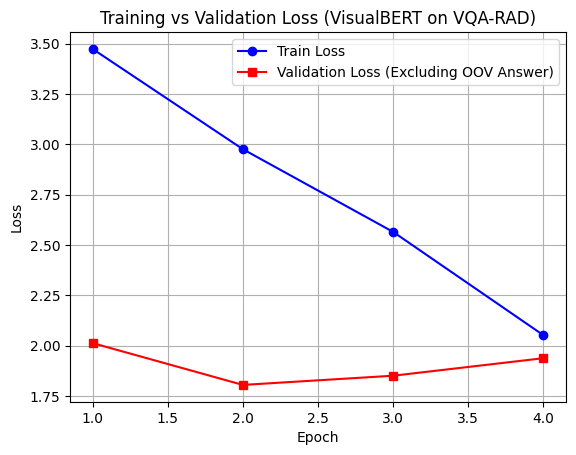

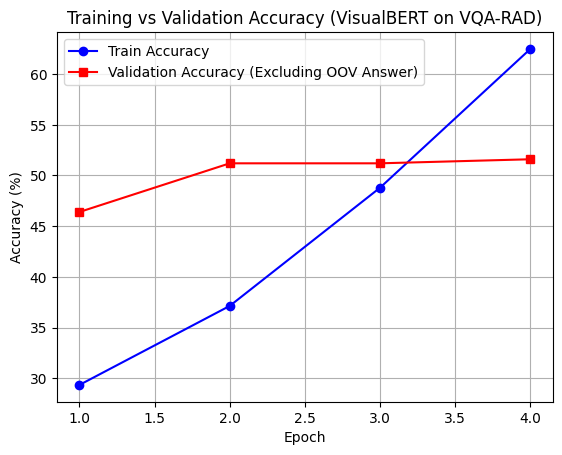


===== VQA-RAD OOV PERCENTAGE =====
VQA-RAD OOV RATE: 77.88%

===== MODEL PERFORMANCE ON TEST DATA INCLUDING OOV =====

Test Loss: 7.3578 | Test Accuracy: 10.27%

===== MODEL PERFORMANCE ON TEST DATA EXCLUDING OOV =====

Test Loss: 1.9401 | Test Accuracy: 52.54%


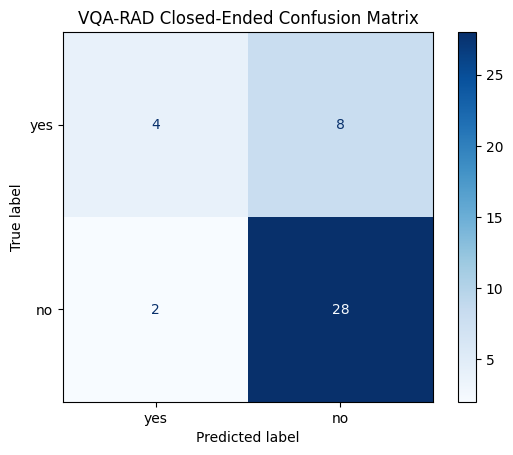

Closed answer indices: [230, 394]
Number of closed-ended samples: 42


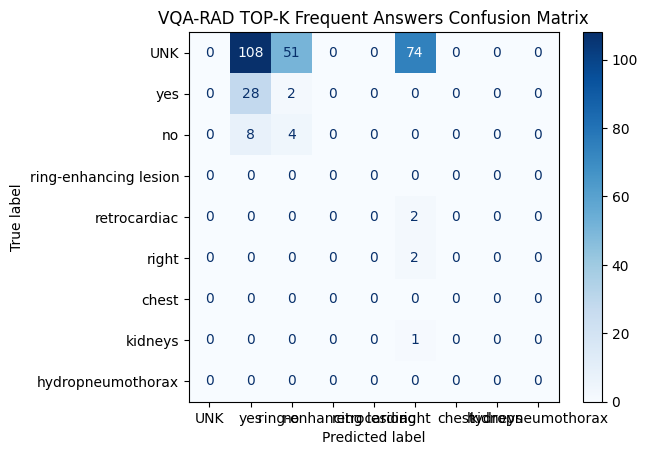


===== GROUND TRUTH EVALUATION FOR OPEN-ENDED=====



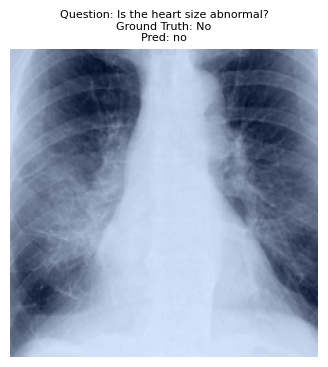

[SAMPLE 1] Question: Is the heart size abnormal? | Ground Truth: No | Pred: no


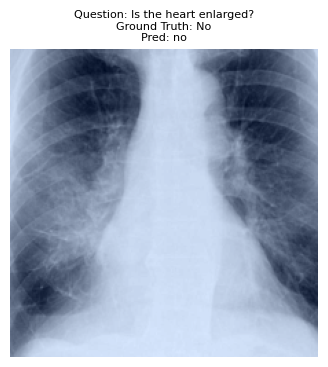

[SAMPLE 2] Question: Is the heart enlarged? | Ground Truth: No | Pred: no


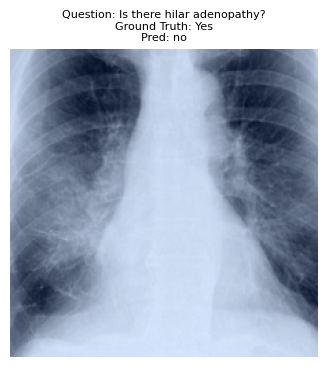

[SAMPLE 3] Question: Is there hilar adenopathy? | Ground Truth: Yes | Pred: no


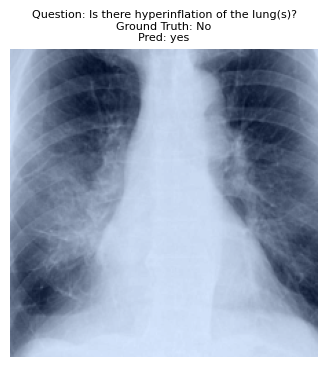

[SAMPLE 4] Question: Is there hyperinflation of the lung(s)? | Ground Truth: No | Pred: yes


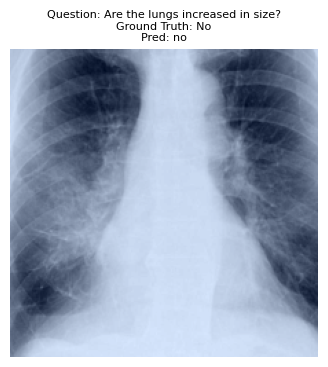

[SAMPLE 5] Question: Are the lungs increased in size? | Ground Truth: No | Pred: no


In [16]:
main_vqa()